In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "phase4_eda"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
hourly = pd.read_csv(
    PROCESSED_DIR / "air_quality_features.csv",
    parse_dates=['time'],
    index_col='time'
)

In [4]:
daily = pd.read_csv(
    PROCESSED_DIR / "air_quality_daily.csv",
    parse_dates=['time'],
    index_col='time'
)

In [5]:
print("Hourly:", hourly.shape)
print("Daily:", daily.shape)

print(
    "Hourly period:",
    hourly.index.min(),
    "to",
    hourly.index.max()
)

print(
    "Daily period:",
    daily.index.min(),
    "to",
    daily.index.max()
)

Hourly: (23352, 43)
Daily: (973, 30)
Hourly period: 2022-09-01 00:00:00 to 2025-04-30 23:00:00
Daily period: 2022-09-01 00:00:00 to 2025-04-30 00:00:00


In [6]:
#categorical ordering
season_order = [
    'Winter',
    'Pre-Monsoon',
    'Monsoon',
    'Post-Monsoon'
]

hourly['season'] = pd.Categorical(
    hourly['season'],
    categories=season_order,
    ordered=True
)

daily['season'] = pd.Categorical(
    daily['season'],
    categories=season_order,
    ordered=True
)

In [7]:
wind_order = [
    'N', 'NE', 'E', 'SE',
    'S', 'SW', 'W', 'NW'
]

hourly['wind_sector'] = pd.Categorical(
    hourly['wind_sector'],
    categories=wind_order,
    ordered=True
)

In [8]:
aqi_order = [
    'Good',
    'Moderate',
    'Unhealthy for Sensitive Groups',
    'Unhealthy',
    'Very Unhealthy',
    'Hazardous'
]

daily['particle_aqi_category'] = pd.Categorical(
    daily['particle_aqi_category'],
    categories=aqi_order,
    ordered=True
)

In [9]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

In [10]:
#variable group
pollutants = [
    'pm25',
    'pm10',
    'no2',
    'so2',
    'co'
]

weather_variables = [
    'temperature',
    'rain',
    'wind_speed',
    'humidity',
    'pressure',
    'dew_point'
]

## Detailed pollutant descriptive statistics

In [11]:
pollution_summary = pd.DataFrame({
    'count': hourly[pollutants].count(),
    'mean': hourly[pollutants].mean(),
    'median': hourly[pollutants].median(),
    'std': hourly[pollutants].std(),
    'min': hourly[pollutants].min(),
    'q1': hourly[pollutants].quantile(0.25),
    'q3': hourly[pollutants].quantile(0.75),
    'max': hourly[pollutants].max(),
    'skewness': hourly[pollutants].skew(),
    'kurtosis': hourly[pollutants].kurtosis()
})

pollution_summary.round(2)

,count,mean,median,std,min,q1,q3,max,skewness,kurtosis
pm25,23352,35.05,29.0,23.25,0.2,18.8,44.6,170.4,1.53,2.82
pm10,23352,48.61,42.3,28.37,0.3,27.4,64.5,221.2,1.05,1.23
no2,23352,14.27,10.6,13.57,0.0,3.7,20.7,107.3,1.66,3.69
so2,23352,6.77,5.6,4.77,0.0,3.7,8.3,37.5,2.05,5.75
co,23352,669.84,523.0,469.38,59.0,333.0,839.0,3204.0,1.69,3.05


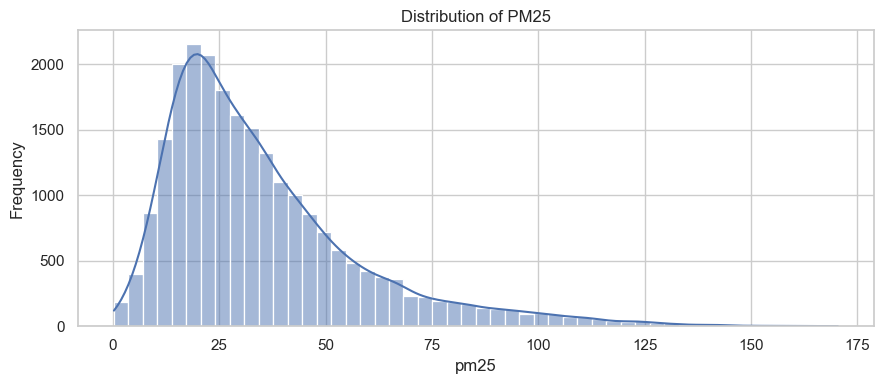

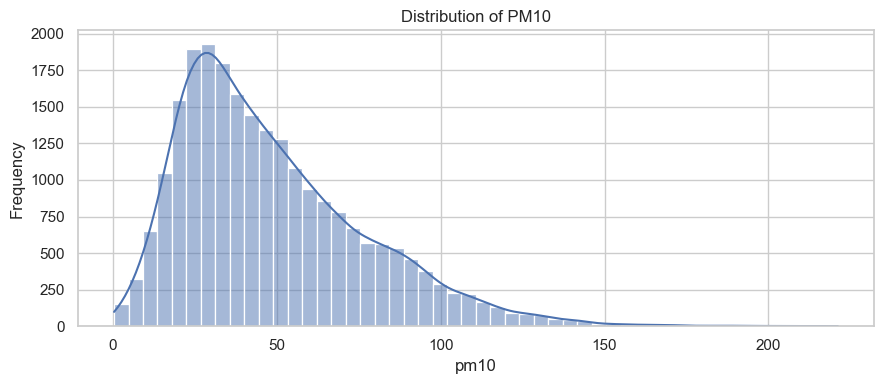

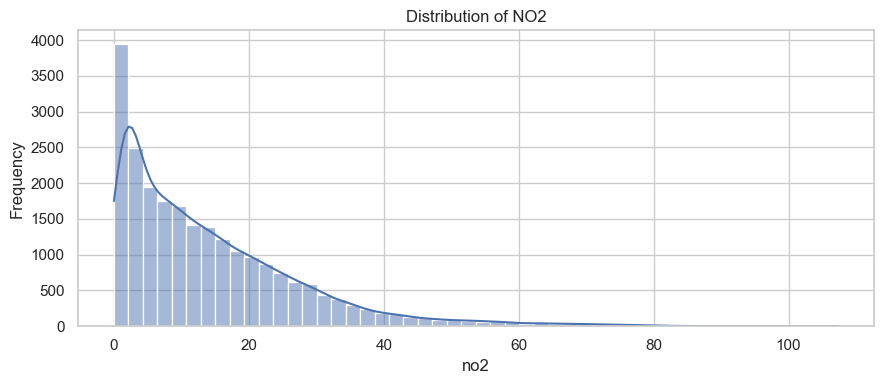

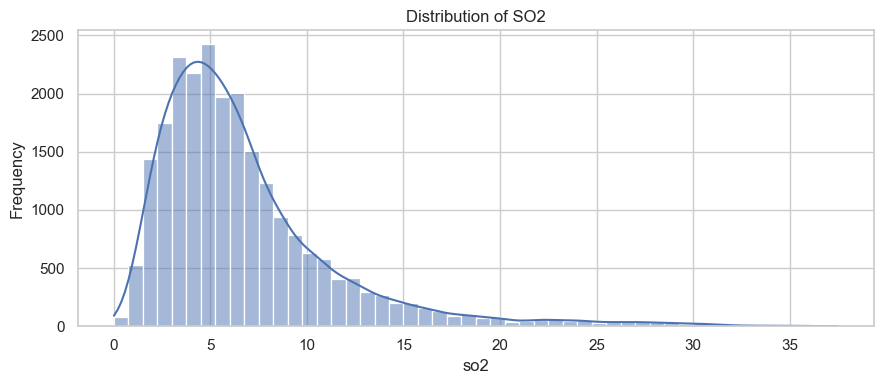

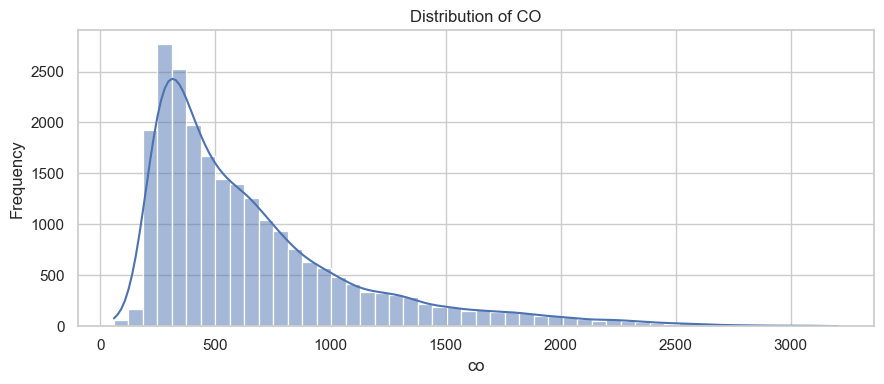

In [12]:
#pollutant distribution
for pollutant in pollutants:

    fig, ax = plt.subplots(figsize=(9, 4))

    sns.histplot(
        data=hourly,
        x=pollutant,
        bins=50,
        kde=True,
        ax=ax
    )

    ax.set_title(
        f'Distribution of {pollutant.upper()}'
    )

    ax.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()